# EXAMPLE BLADE DAVIDE

In [ ]:
import Airfoil_Section2
import pickle
#BEMT Analysis
from BEMT_Solver import PropellerParameters, PropellerAnalysis, SectionForces

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

with open("test_blade.pkl", "rb") as f:
    BEMT_input = pickle.load(f)

BEMT_input.keys()
BEMT_input["twist"] = BEMT_input.pop("twistDeg")

In [ ]:
# BEMT preparation
"""BEMT analysis"""
# Global Propeller Parameters
prop_radius = BEMT_input['tip_radius']
hub_radius = BEMT_input['hub_radius']
n_blades = BEMT_input['n_blades']

# Operating conditions
RPM = 7000
v_inf = 0.0

# Fluid Parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343

# Define global parameters
propeller_parameters = PropellerParameters(
    prop_radius=prop_radius,
    hub_radius=hub_radius,
    n_blades=n_blades,
    RPM=RPM,
    v_inf=v_inf,
    a_inf=a_inf,
    rho=rho,
    mu=mu
)

# Define propeller analysis
propeller_analysis = PropellerAnalysis(
    propeller_geometry=BEMT_input,
    propeller_params=propeller_parameters
)

# Run propeller analysis
n_jobs = 1
propeller_analysis.run_BEMT(n_jobs=n_jobs)

In [ ]:
# BEMT preparation
"""BEMT analysis"""
# Global Propeller Parameters
prop_radius = BEMT_input['tip_radius']
hub_radius = BEMT_input['hub_radius']
n_blades = BEMT_input['n_blades']

# Operating conditions
RPM = 7000
v_inf = 0.0

# Fluid Parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343


# Define propeller analysis
propeller_analysis_const = PropellerAnalysis(
    propeller_geometry=BEMT_input,
    propeller_params=propeller_parameters,
    Re=1e5,
    Ma=0.01,
    use_consistent_Re_Ma=False,
)

# Run propeller analysis
n_jobs = 1
propeller_analysis_const.run_BEMT(n_jobs=n_jobs)

In [ ]:
section_indices = [len(BEMT_input['r']) - 3, len(BEMT_input['r']) - 2, len(BEMT_input['r']) - 1]
labels = ["Third-Last Section", "Second-Last Section", "Last Section"]
colors = ['tab:blue', 'tab:red', 'tab:green']

# Create multi-subplot figure
fig, axs = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
axs = axs.flatten()

for idx, section_nr in enumerate(section_indices):
    r = BEMT_input['r'][section_nr]
    dr = BEMT_input['dr'][section_nr]
    chord = BEMT_input['chord'][section_nr]
    theta = BEMT_input['twist'][section_nr]
    x_coordinates = BEMT_input['airfoil'][section_nr].X
    y_coordinates = BEMT_input['airfoil'][section_nr].Y

    phi_deg = np.linspace(0.1, 359.9, 50)
    phi_rad = np.radians(phi_deg)

    residual_alt = []
    F_vals = []
    u_vals = []
    cl_vals = []
    cd_vals = []
    clp_vals = []
    cdp_vals = []
    alpha_vals = []
    chord_vals = []

    section_alt = SectionForces(
        np.array([x_coordinates, y_coordinates]).T,
        r, dr, chord, theta, propeller_parameters
    )

    for phi in phi_rad:
        try:
            alpha, c_l, c_d, F, u, a_prime, W, c_l_prime, c_d_prime = section_alt.section_parameters(phi)
            res = section_alt.residual_function(phi)
        except Exception:
            alpha, c_l, c_d, F, u, a_prime, W, c_l_prime, c_d_prime, res = [np.nan] * 10

        residual_alt.append(res)
        chord_vals.append(chord)
        F_vals.append(F)
        u_vals.append(u)
        alpha_vals.append(alpha)
        cl_vals.append(c_l)
        cd_vals.append(c_d)
        clp_vals.append(c_l_prime)
        cdp_vals.append(c_d_prime)

    # Plot all on same axes
    axs[0].semilogx(phi_deg, residual_alt, label=f"{labels[idx]} (r={r:.3f} m)", color=colors[idx], marker='.')
    axs[1].plot(phi_deg, F_vals, label=f"{labels[idx]}", color=colors[idx], marker='.')
    axs[2].plot(phi_deg, u_vals, label=f"{labels[idx]}", color=colors[idx], marker='.')
    axs[3].plot(phi_deg, alpha_vals, label=f"{labels[idx]}", color=colors[idx], marker='.')
    axs[4].plot(phi_deg, cl_vals, label=f"Cl – {labels[idx]}", color=colors[idx], marker='.')
    axs[4].plot(phi_deg, cd_vals, label=f"Cd – {labels[idx]}", color=colors[idx], linestyle='--', marker='.')
    axs[5].plot(phi_deg, clp_vals, label=f"Cn' – {labels[idx]}", color=colors[idx], marker='.')
    axs[5].plot(phi_deg, cdp_vals, label=f"Ct' – {labels[idx]}", color=colors[idx], linestyle='--', marker='.')
    axs[6].plot(phi_deg, chord_vals, label=f"chord' – {labels[idx]}", color=colors[idx], marker='.')
    axs[6].plot(phi_deg, chord_vals, label=f"chord' – {labels[idx]}", color=colors[idx], linestyle='--', marker='.')

# Styling
for ax in axs:
    ax.grid(True)
    ax.set_xlim([-5, 365])
    ax.axhline(0, color='gray', linestyle='--')
    for phi_vert in [0, 90, 180, 270, 360]:
        ax.axvline(phi_vert, color='gray', linestyle='--', linewidth=0.8)

# Axis labels and limits
axs[0].set_ylabel("Residual"); axs[0].set_ylim([-1, 1])
axs[1].set_ylabel("F(φ)"); axs[1].set_ylim([0, 1])
axs[2].set_ylabel("u [m/s]"); axs[2].set_ylim([-100, 100])
axs[3].set_ylabel("alpha [deg]")
axs[4].set_ylabel("Cl, Cd"); axs[4].set_ylim([-3, 3])
axs[5].set_ylabel("Cn, Ct"); axs[5].set_ylim([-3, 3])
axs[6].set_ylabel("chord")

for ax in axs:
    ax.set_xlabel("Phi [deg]")
    ax.legend()

fig.suptitle("BEMT Diagnostics: Second-to-Last vs Last Blade Section", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
lower_phi = 0.001
upper_phi = 359.999
phi_deg = np.linspace(lower_phi, upper_phi, 50)
phi_rad = np.radians(phi_deg)

# Create diagnostic arrays
residual_alt = []
F_vals = []
u_vals = []
cl_vals = []
cd_vals = []
clp_vals = []
cdp_vals = []
alpha_vals = []

# Define and initialize section
section_alt = SectionForces(
    np.array([x_coordinates, y_coordinates]).T,
    r, dr, chord, theta, propeller_parameters
)

for phi in phi_rad:
    try:
        alpha, c_l, c_d, F, u, a_prime, W, c_l_prime, c_d_prime = section_alt.section_parameters(phi)
        res = section_alt.residual_function(phi)
    except Exception:
        alpha, c_l, c_d, F, u, a_prime, W, c_l_prime, c_d_prime, res = [np.nan] * 10

    residual_alt.append(res)
    F_vals.append(F)
    u_vals.append(u)
    alpha_vals.append(alpha)
    cl_vals.append(c_l)
    cd_vals.append(c_d)
    clp_vals.append(c_l_prime)
    cdp_vals.append(c_d_prime)

# Create multi-subplot figure
fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axs = axs.flatten()

axs[0].plot(phi_deg, residual_alt, label="Residual", color='tab:blue', marker='.')
axs[0].set_ylabel("Residual")
axs[0].set_ylim([-1, 1])
axs[0].legend()

axs[1].plot(phi_deg, F_vals, label="Prandtl Loss F", color='tab:orange', marker='.')
axs[1].set_ylabel("F(φ)")
axs[1].set_ylim([0, 1])
axs[1].legend()

axs[2].plot(phi_deg, u_vals, label="u(φ)", color='tab:green', marker='.')
axs[2].set_ylabel("u [m/s]")
axs[2].set_ylim([-100, 100])
axs[2].legend()

axs[3].plot(phi_deg, alpha_vals, label="alpha(φ)", color='yellow', marker='.')
axs[3].set_ylabel("alpha [deg]")
axs[3].legend()

axs[4].plot(phi_deg, cl_vals, label="Cl", color='tab:red', marker='.')
axs[4].plot(phi_deg, cd_vals, label="Cd", color='tab:purple', marker='.')
axs[4].set_ylabel("Cl, Cd")
axs[4].set_ylim([-3, 3])
axs[4].legend()

axs[5].plot(phi_deg, clp_vals, label="Cn'", color='tab:brown', marker='.')
axs[5].plot(phi_deg, cdp_vals, label="Ct'", color='tab:pink', marker='.')
axs[5].set_ylabel("Cn, Ct")
axs[5].set_ylim([-3, 3])
axs[5].legend()


# Common x-label and formatting
for ax in axs:
    ax.grid(True)
    ax.set_xlim([-5, 365])
    ax.axhline(0, color='gray', linestyle='--')
    for phi_vert in [0, 90, 180, 270, 360]:
        ax.axvline(phi_vert, color='gray', linestyle='--', linewidth=0.8)

axs[5].set_xlabel("Phi [deg]")
axs[4].set_xlabel("Phi [deg]")
axs[3].set_xlabel("Phi [deg]")
axs[2].set_xlabel("Phi [deg]")
axs[1].set_xlabel("Phi [deg]")
axs[0].set_xlabel("Phi [deg]")

fig.suptitle(f"BEMT Diagnostics for Section #{section_nr} at r = {r:.4f} m", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os

#Geometry creation
from APC_Reader import APC_Reader
from BEMT_Blade import BEMT_Blade

#BEMT Analysis
from BEMT_Solver import PropellerParameters, PropellerAnalysis, SectionForces

#Acoustic Analysis
from Acoustic_Solver import CompactSourceElement, AcousticObserver 
from Observer_Manager import ObserverManager

#UIUC
"""import sys
sys.path.append('./Measurement Interpretation')
from UI"""

"import sys\nsys.path.append('./Measurement Interpretation')\nfrom UI"

## GEOMETRY READER

In [2]:
"""READ PROPELLER GEOMETRY AND EXTRACT BEMT INPUT"""
propeller_name = "11x7E"
reader = APC_Reader(os.getcwd() + fr"\APC Propeller Geometry Data\{propeller_name}-PERF.PE0")

In [3]:
"""CONSTRUCT DATA FOR SIMULATION"""
blade = BEMT_Blade(reader, interpolation_points=200)
BEMT_input = blade.export_geometry_for_analysis()

## BEMT ANALYSIS

In [4]:
"""BEMT analysis"""
# Global Propeller Parameters
prop_radius = BEMT_input['tip_radius']
hub_radius = BEMT_input['hub_radius']
n_blades = BEMT_input['n_blades']

# Operating conditions
RPM = 3000
v_inf = 0.0

# Fluid Parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343

# Define propeller parameters
propeller_parameters = PropellerParameters(
    prop_radius=prop_radius,
    hub_radius=hub_radius,
    n_blades=n_blades,
    RPM=RPM,
    v_inf=v_inf,
    a_inf=a_inf,
    rho=rho,
    mu=mu
)

# Define propeller analysis
propeller_analysis_const = PropellerAnalysis(
    propeller_geometry=BEMT_input,
    propeller_params=propeller_parameters,
    Re = 1e5,
    Ma = 0.01,
    use_consistent_Re_Ma=False
)

# Define propeller analysis
propeller_analysis_varied = PropellerAnalysis(
    propeller_geometry=BEMT_input,
    propeller_params=propeller_parameters,
    use_consistent_Re_Ma=True
)

# Run propeller analysis
n_jobs = 12
propeller_analysis_const.run_BEMT(n_jobs=n_jobs)
propeller_analysis_varied.run_BEMT(n_jobs=n_jobs)

In [5]:
const_sol = propeller_analysis_const.solution_data
varied_sol = propeller_analysis_varied.solution_data

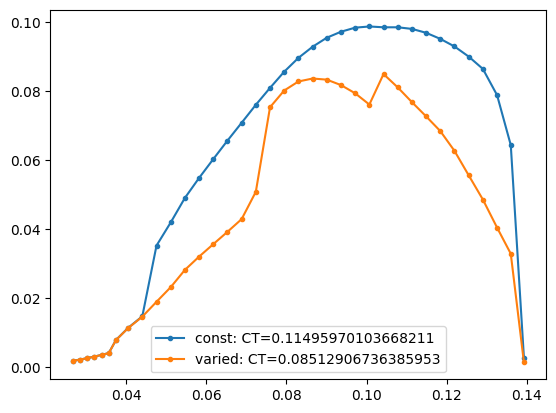

In [6]:
%matplotlib inline
plt.plot(const_sol['radius'], const_sol['dT'], label=f'const: CT={propeller_analysis_const.compute_total_forces()[2]}', marker='.')
plt.plot(varied_sol['radius'], varied_sol['dT'], label=f'varied: CT={propeller_analysis_varied.compute_total_forces()[2]}', marker='.')
plt.legend()
plt.show()

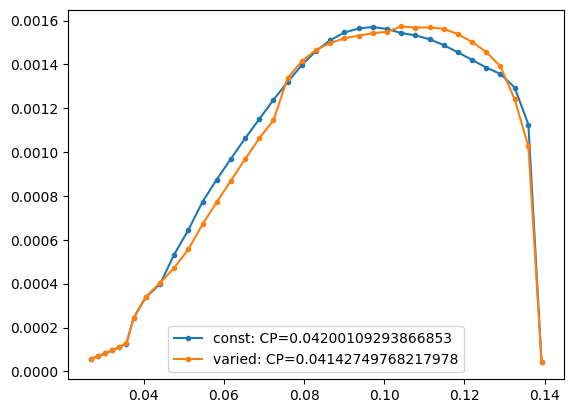

In [7]:
%matplotlib inline
plt.plot(const_sol['radius'], const_sol['dQ'], label=f'const: CP={propeller_analysis_const.compute_total_forces()[3]}', marker='.')
plt.plot(varied_sol['radius'], varied_sol['dQ'], label=f'varied: CP={propeller_analysis_varied.compute_total_forces()[3]}', marker='.')
plt.legend()
plt.show()

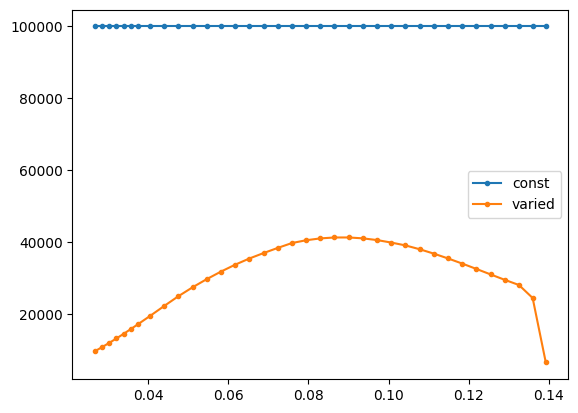

In [8]:
plt.plot(const_sol['radius'], const_sol['Re'], label='const', marker='.')
plt.plot(varied_sol['radius'], varied_sol['Re'], label='varied', marker='.')
plt.legend()
plt.show()

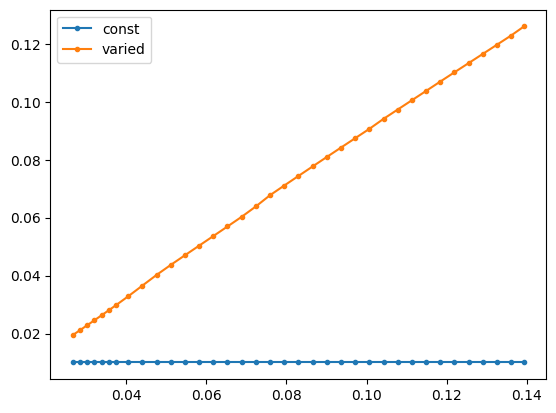

In [9]:
plt.plot(const_sol['radius'], const_sol['Ma'], label='const', marker='.')
plt.plot(varied_sol['radius'], varied_sol['Ma'], label='varied', marker='.')
plt.legend()
plt.show()

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

ncols = 5
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12))
axes = axes.flatten()

for i, label in enumerate(standard_sol.columns):
    ax = axes[i]
    ax.plot(standard_sol['radius'], standard_sol[label], label='standard', linewidth=2, marker='o')
    ax.plot(alternative_sol['radius'], alternative_sol[label], label='alternative', linestyle='--', linewidth=2, marker='*')
    ax.plot(standard_sol['radius'], standard_sol[label] - alternative_sol[label], label='difference', linestyle=':', linewidth=2, marker='x')
    ax.set_title(label)
    ax.grid(True)
    ax.legend(fontsize=8)

# Remove empty subplots
for j in range(len(standard_sol.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import aerosandbox as asb

# --- Define helper functions ---
def solidity(n_blades, chord, r):
    return n_blades * chord / (2 * np.pi * r)

def prandtl_loss(phi, n_blades, r, prop_radius, hub_radius):
    def prandtl(d_r, r, phi):
        f = n_blades * d_r / (2 * r * np.sin(phi))
        return np.where(
            -f > 500, 
            1.0, 
            2 * np.arccos(np.clip(np.exp(-f), 0, 1)) / np.pi
        )
    phi = np.where(phi == 0, 1e-6, phi)  # Avoid division by zero
    Ftip = prandtl(prop_radius - r, r, phi)
    Fhub = prandtl(hub_radius, r, phi)
    return Ftip * Fhub

def c_n(phi, cl, cd):
    return cl * np.cos(phi) - cd * np.sin(phi)

# --- Parameters ---
r = 0.1269
r_tip = 0.127
r_hub = 0.01016
n_blades = 2

chord = 0.001  # m
cl = 0.1
cd = 0.01

# --- Residual function ---
R = lambda phi: (
    np.tan(phi) - solidity(n_blades, chord, r) * (c_n(phi, cl, cd) / (4 * prandtl_loss(phi, n_blades, r, r_tip, r_hub))) * (1 / (np.cos(phi) * np.sin(phi)))
)

# --- Plot ---
phi_deg = np.linspace(-89.9, 89.9, 50)  # degrees
phi_rad = np.radians(phi_deg)
R_vals = R(phi_rad)

plt.plot(phi_deg, R_vals, label='R(phi)', marker='o')
plt.xlabel("phi [deg]")
plt.ylabel("R(phi)")
#plt.ylim([-1, 1])
plt.xlim([-90, 90])
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.grid(True)
plt.legend()
plt.title("Residual R(phi) vs phi")
plt.show()


## ACOUTSTIC ANALYSIS

In [ ]:
#Temporal discretization in observer coordinate system
revolutions = 6
omega = 2*np.pi * RPM/60
duration = revolutions * (2*np.pi/omega) 
blade_passing_period = duration / revolutions / n_blades
observer_time_range = revolutions*blade_passing_period
num_obs_times = 50*revolutions

#Temporal discretization in source coordinate system
n_source_times = 2*num_obs_times
dt = duration/(n_source_times-1)
src_times = np.arange(0,n_source_times)*dt

#Prepare data for acoustic analysis
radial_section = BEMT_input['r']
n_sections = len(radial_section)
dr = BEMT_input['dr']
blade_angles = 2*np.pi/n_blades * np.arange(0, n_blades)
airfoil_area = []
COM_x = []
COM_y = []
for i in range(len(BEMT_input['airfoil'])):
        #airfoil_area.append(BEMT_input['airfoil'][i]._APC_cross_section_area * 0.0254**2)
        airfoil_area.append(BEMT_input['airfoil'][i].calculate_cross_section_area() * BEMT_input['chord'][i]**2)
        COM_x.append(BEMT_input['COM_shift'][i][0])
        COM_y.append(BEMT_input['COM_shift'][i][1])
dT = propeller_analysis.solution_data['dT'] / BEMT_input['dr'] / n_blades
dQ = propeller_analysis.solution_data['dQ'] / BEMT_input['dr'] / BEMT_input['r'] / n_blades
dR = np.zeros_like(dT)

In [ ]:
#Define acoustic observer object
r_observer = [[0, 1.8, 0],
              [1.8, 0, 0],
              [0, 0, 1.8]]
observer_manager = ObserverManager().from_positions(r_observer)


for observer in observer_manager:

    #Construct compact source elements, apply coordinate transformation from \nu to y-frame, compute observer times for all compact elements and perform f1a calculation
    compact_source_elements = np.empty((n_source_times, n_sections, n_blades), dtype=object)
    observer_time = np.empty((n_source_times, n_sections, n_blades), dtype=float)
    F1A_output = np.empty((n_source_times, n_sections, n_blades), dtype=object)

    for i in range(n_source_times):
        for j in range(n_sections):
            for k in range(n_blades):
                #compact source element
                element = CompactSourceElement.from_params(
                    rho, a_inf, radial_section[j], blade_angles[k], COM_x[j], COM_y[j], dr[j], airfoil_area[j] , -dT[j] , dR[j], dQ[j], src_times[i]
                )
                compact_source_elements[i,j,k] = element.coordinate_transform(omega=omega, v_inf=v_inf)

                #observer time
                obs_time = element.time_to_observer(observer)
                observer_time[i,j,k] = obs_time

                #f1a calculation
                f1a_output = element.f1a_calculation(element, observer, obs_time)
                F1A_output[i,j,k] = f1a_output

    #combine the source elements at the observer position
    observer.combine_source_elements(f1a_output=F1A_output, time_range=observer_time_range, n_common_time_steps=num_obs_times)

In [ ]:
#plot results
observer = observer_manager[2]

%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(7)
fig.set_figwidth(15)
fontsize=10
labelsize=10

axs[0].plot(observer.t, observer.p_m, marker='.', label='monopole pressure')
axs[0].plot(observer.t, observer.p_d, marker='.', label='dipole pressure')
axs[0].plot(observer.t, observer.p_m+observer.p_d, marker='.', label='total pressure')
axs[0].set_xlabel('Time [s]', fontsize=fontsize)
axs[0].set_ylabel('Acoustic pressure [Pa]', fontsize=fontsize)
axs[0].grid(True)
axs[0].legend()

axs[1].semilogx(observer.frequency, observer.SPL, marker='.', label=f'OSPL: {observer.OSPL:.2f} dB')
axs[1].set_xlabel('Frequency [Hz]', fontsize=fontsize)
axs[1].set_ylabel('SPL [dB]', fontsize=fontsize)
axs[1].grid(True)
axs[1].legend()